### Introduction
* Import necessary libraries and load data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../../datasets/raw/diabetes.csv")
print(df.shape)

(100000, 9)


* Inspect data

In [ ]:
print(df.columns)
print(df.info())
print(df.describe().T)

* Check for Missing data

In [2]:
missing = df.isnull().sum()
print(missing[missing>0])

Series([], dtype: int64)


* Check for Duplicates

In [3]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 3854


**drop duplicates**

In [4]:
df.drop_duplicates()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99994,Female,36.0,0,0,No Info,24.60,4.8,145,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


* Uniqueness

In [5]:
for column in df.columns:
    distinct = len(df[column].unique())
    print(f"{column}: {distinct} distinct values")

gender: 3 distinct values
age: 102 distinct values
hypertension: 2 distinct values
heart_disease: 2 distinct values
smoking_history: 6 distinct values
bmi: 4247 distinct values
HbA1c_level: 18 distinct values
blood_glucose_level: 18 distinct values
diabetes: 2 distinct values


### Univariate Analysis

* Numerical statistics

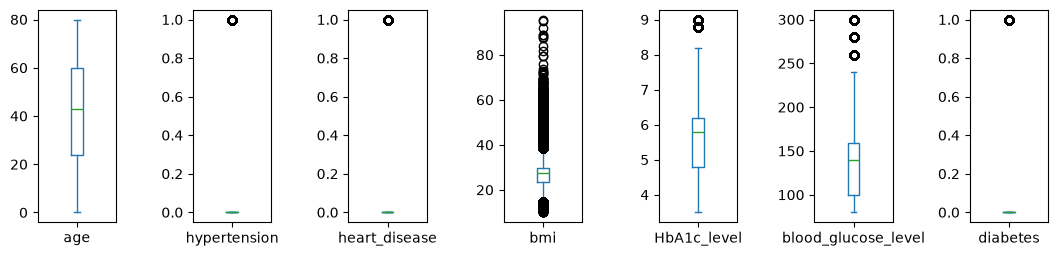

In [6]:
numerical_cols = df.select_dtypes(include="number")

numerical_cols.plot(
    kind="box",
    subplots=True,
    layout=(8, 13),
    figsize=(20, 20)
)

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(30,30), facecolor="lightblue")

plt.subplot(4,4,1)
ax = sns.countplot(data=df, x="diabetes", edgecolor="black")
ax.bar_label(ax.containers[0]) # type: ignore
plt.title("Diabetes Distribution")

plt.subplot(4,4,2)
ax = sns.countplot(data=df, x="gender", edgecolor="black")
ax.bar_label(ax.containers[0]) # type: ignore
plt.xlabel("gender")
plt.ylabel("count")
plt.title("Gender Distribution")

plt.subplot(4,4,3)
sns.histplot(data=df, x="age", edgecolor="black")
plt.xlabel("age")
plt.ylabel("count")
plt.title("Age Distribution")

plt.subplot(4,4,4)
ax = sns.countplot(data=df, x="heart_disease", edgecolor="black")
ax.bar_label(ax.containers[0]) # type: ignore
plt.title("Heart Disease Distribution")

plt.subplot(4,4,5)
ax = sns.countplot(data=df, x="hypertension", edgecolor="black")
ax.bar_label(ax.containers[0]) # type: ignore
plt.title("Hypertension Distribution")

plt.subplot(4,4,6)
ax = sns.countplot(data=df, x="smoking_history", edgecolor="black")
ax.bar_label(ax.containers[0]) # type: ignore
plt.title("Smoking Distribution")

plt.subplot(4,4,7)
sns.histplot(data=df, x="bmi", stat="density", kde=True)
plt.xlabel("bmi")
plt.ylabel("density")
plt.title("BMI Distribution")

plt.subplot(4,4,8)
sns.histplot(data=df, x="blood_glucose_level", bins=20, stat="density", kde=True)
plt.xlabel("blood_glucose_level")
plt.ylabel("density")
plt.title("Blood Glucose Distribution")

plt.subplot(4,4,9)
sns.histplot(data=df, x="HbA1c_level", kde=True)
plt.xlabel("HbA1c Level")
plt.ylabel("Density")
plt.title("HbA1c Level Distribution")

plt.tight_layout()
plt.show()

### Bivariate Analysis

In [7]:
num_cols = (
    df.groupby("diabetes")
    [["age", "bmi", "HbA1c_level", "blood_glucose_level"]]
    .agg(["mean", "median", "std"])
    .unstack()
)
print(num_cols)

                             diabetes
age                  mean    0            40.115187
                             1            60.946588
                     median  0            40.000000
                             1            62.000000
                     std     0            22.306005
                             1            14.549880
bmi                  mean    0            26.887163
                             1            31.988382
                     median  0            27.320000
                             1            29.970000
                     std     0             6.373406
                             1             7.558371
HbA1c_level          mean    0             5.396761
                             1             6.934953
                     median  0             5.800000
                             1             6.600000
                     std     0             0.971628
                             1             1.076562
blood_glucose_level  mean 

* Gender against Diabetes

In [8]:
gender_diabetes = (
    df.groupby("gender")["diabetes"]
    .aggregate(["mean", "count"])
    .rename(columns={"count": "Total", "mean": "Diabetes Rate"})
    )
print(gender_diabetes)

        Diabetes Rate  Total
gender                      
Female       0.076189  58552
Male         0.097490  41430
Other        0.000000     18


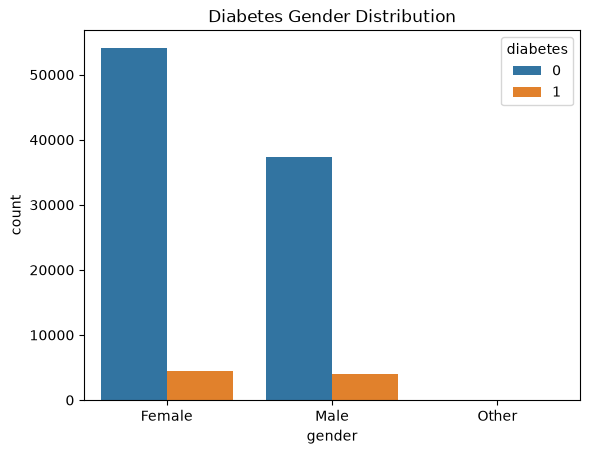

In [9]:
sns.countplot(data=df, x="gender", hue="diabetes")
plt.title("Diabetes Gender Distribution")
plt.show()

* HbA1c_level against Diabetes

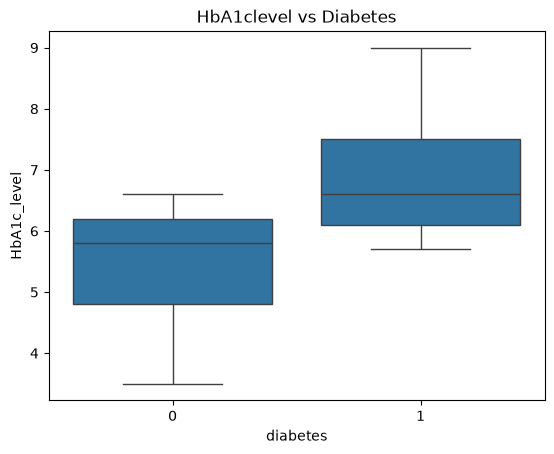

In [10]:
sns.boxplot(data=df, x="diabetes", y="HbA1c_level")
plt.title("HbA1clevel vs Diabetes")
plt.xlabel("diabetes")
plt.ylabel("HbA1c_level")
plt.show()

* BMI against Diabetes

In [11]:
bmi_rate = (
    df.groupby([pd.cut(df["bmi"], bins=[10, 20, 30, 40, 50, 60, 70, 80, 90, 100])])["diabetes"]
    .aggregate(["mean", "count"])
    .rename(columns={"count": "Total", "mean": "Diabetes Rate"})
    )
print(bmi_rate)

           Diabetes Rate  Total
bmi                            
(10, 20]        0.010870  12144
(20, 30]        0.064251  64373
(30, 40]        0.161143  18890
(40, 50]        0.250852   3815
(50, 60]        0.292609    663
(60, 70]        0.322917     96
(70, 80]        0.300000     10
(80, 90]        0.500000      6
(90, 100]       0.000000      3


* Heart disease against Diabetes

                   Rate  Total
heart_disease                 
0              0.075298   7233
1              0.321410   1267


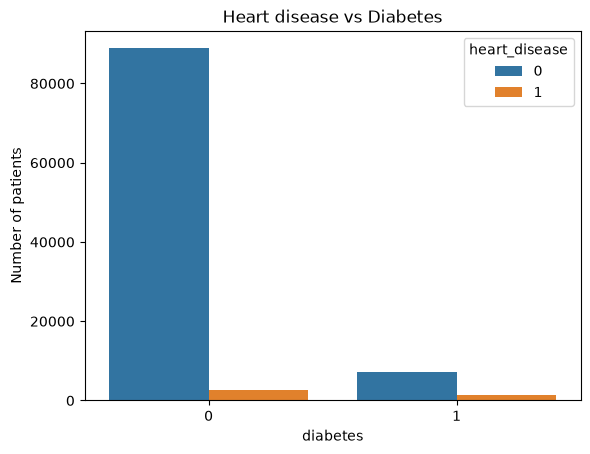

In [12]:
heart_rate = (
    df.groupby(["heart_disease"])["diabetes"]
    .agg(["mean", "sum"])
    .rename(columns={"mean":"Rate", "sum":"Total"})
)
print(heart_rate)

sns.countplot(data=df, x="diabetes", hue="heart_disease")
plt.ylabel("Number of patients")
plt.title("Heart disease vs Diabetes")
plt.show()

* Pair plot on numerical variables

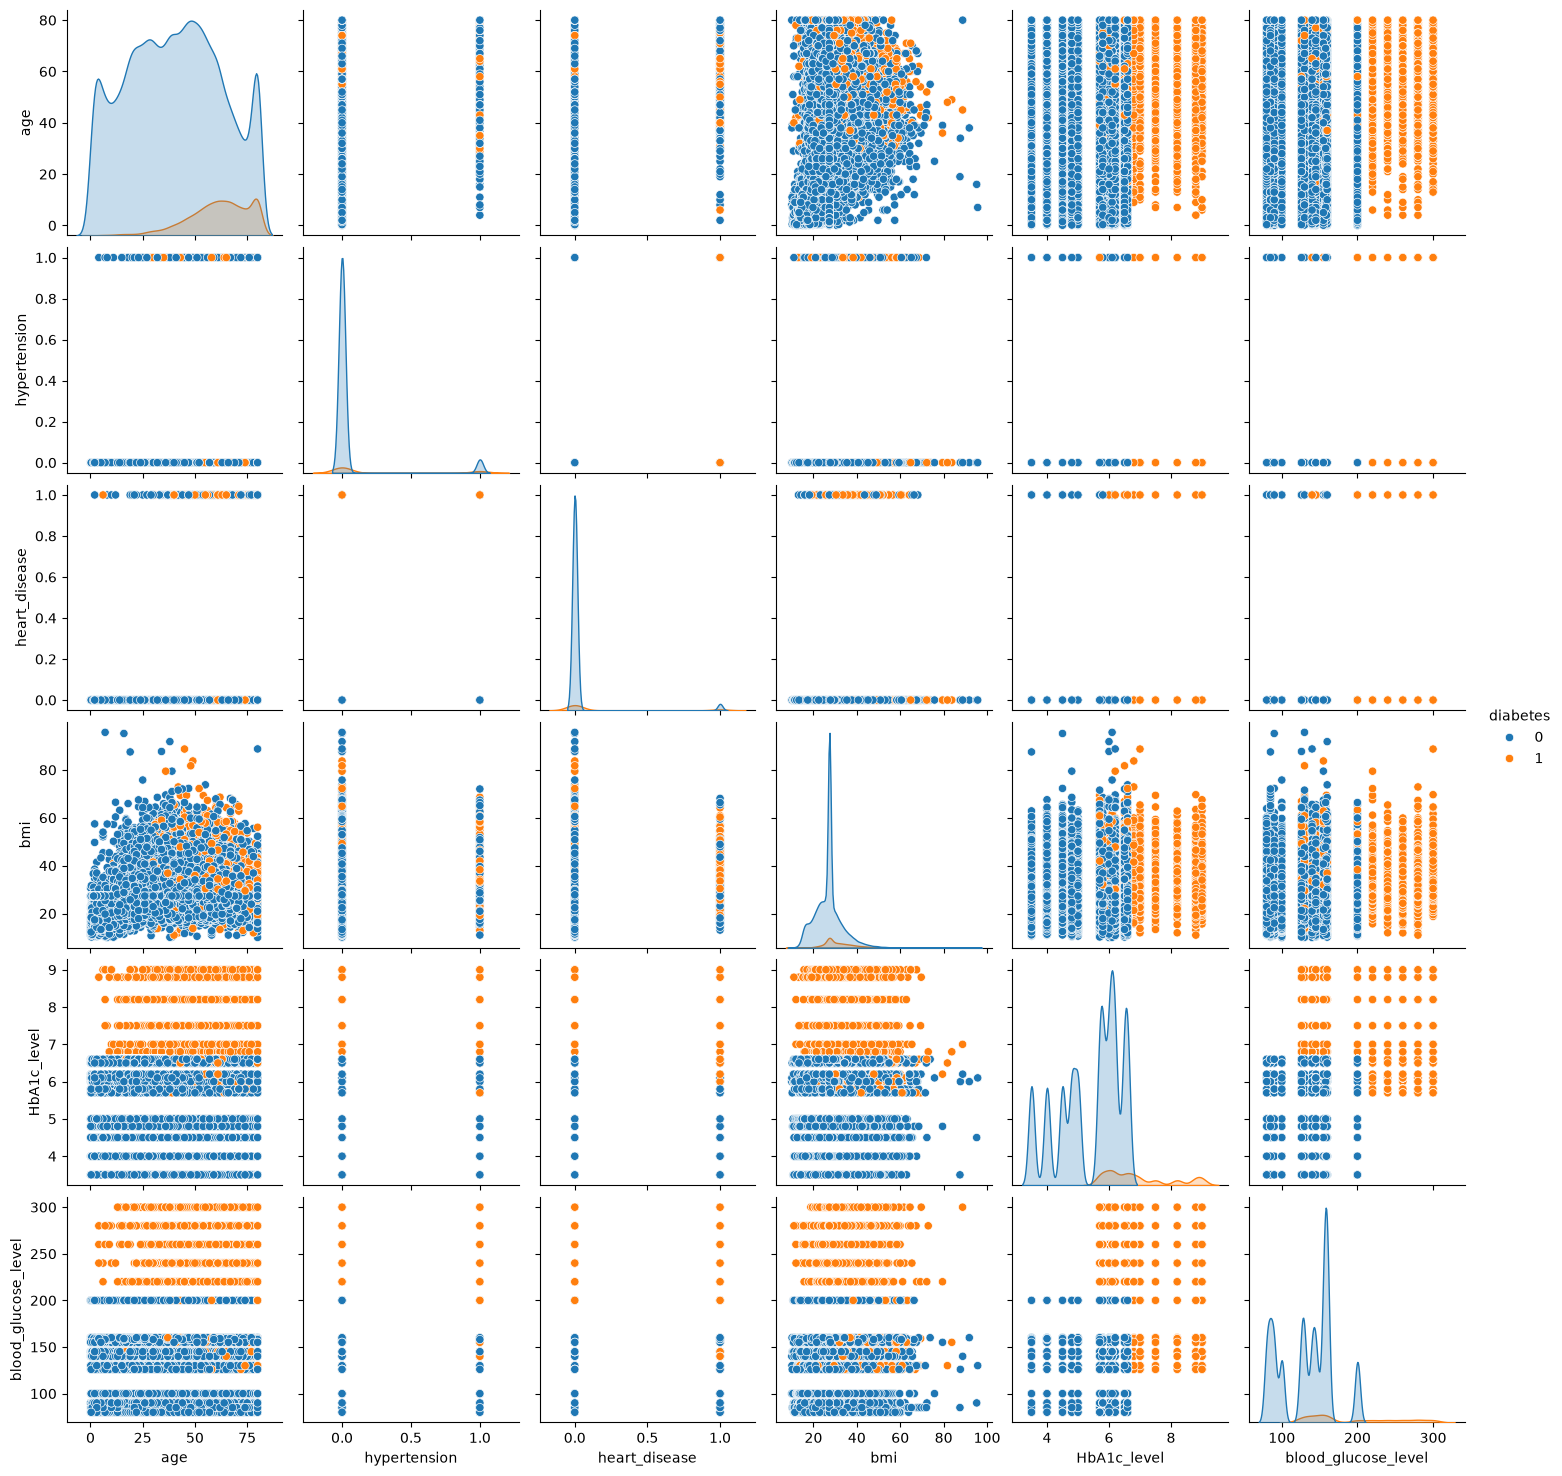

In [13]:
sns.pairplot(data=df, hue="diabetes")
plt.show()

### Multivariate Analysis

* Diabetes prevalence on Age and Blood glucose levels

                        Diabetes Rate  Total
gender smoking_history                      
Female No Info               0.038274  19700
       current               0.089166   5058
       ever                  0.094281   2238
       former                0.135945   4774
       never                 0.087542  22869
       not current           0.100690   3913
Male   No Info               0.043451  16110
       current               0.117550   4228
       ever                  0.147875   1765
       former                0.205548   4578
       never                 0.109957  12223
       not current           0.117181   2526
Other  No Info               0.000000      6
       ever                  0.000000      1
       never                 0.000000      3
       not current           0.000000      8


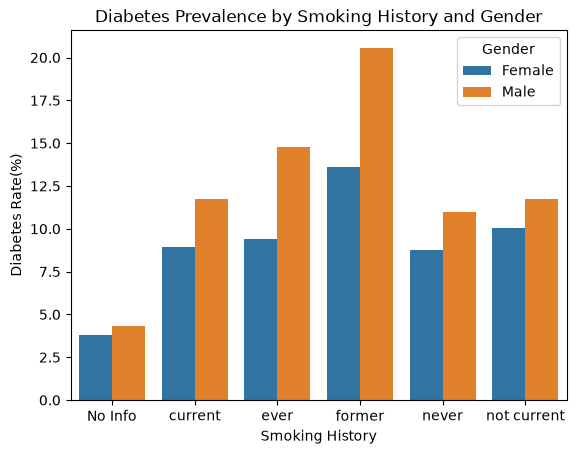

In [14]:
smoking_gender = (
    df.groupby(["gender", "smoking_history"])["diabetes"]
    .agg(["mean", "count"])
    .rename(columns={"mean":"Diabetes Rate", "count":"Total"})
    )
print(smoking_gender)
smoking_gender = (
    df.groupby(["smoking_history", "gender"])["diabetes"]
      .mean()
      .reset_index()
)
smoking_gender["diabetes"] *= 100
smoking_gender = smoking_gender[smoking_gender["gender"] != "Other"]
sns.barplot(data=smoking_gender, x="smoking_history", y="diabetes", hue="gender")
plt.title("Diabetes Prevalence by Smoking History and Gender")
plt.xlabel("Smoking History")
plt.ylabel("Diabetes Rate(%)")
plt.legend(title="Gender")
plt.show()

*Diabetes prevalence varies across smoking-history categories, with former smokers showing the highest observed prevalence in both female and male groups. The pattern also differs across gender as within almost every comparable smoking category, males have a higher observed diabetes rate.*

* Age vs Blood glucose level against Diabetes

                              Diabetes Rate  Total
blood_glucose_level age                           
(80, 100]           (10, 20]       0.000000   2327
                    (20, 30]       0.000000   2863
                    (30, 50]       0.000000   6095
                    (50, 80]       0.000000   7331
(100, 150]          (10, 20]       0.009048   3205
                    (20, 30]       0.016936   3956
                    (30, 50]       0.058789   8556
                    (50, 80]       0.169794  11832
(150, 200]          (10, 20]       0.007387   3926
                    (20, 30]       0.010247   4977
                    (30, 50]       0.045446  10474
                    (50, 80]       0.143037  14290
(200, 250]          (10, 20]       1.000000      6
                    (20, 30]       1.000000     30
                    (30, 50]       1.000000    190
                    (50, 80]       1.000000   1008
(250, 300]          (10, 20]       1.000000     20
                    (20, 30]   

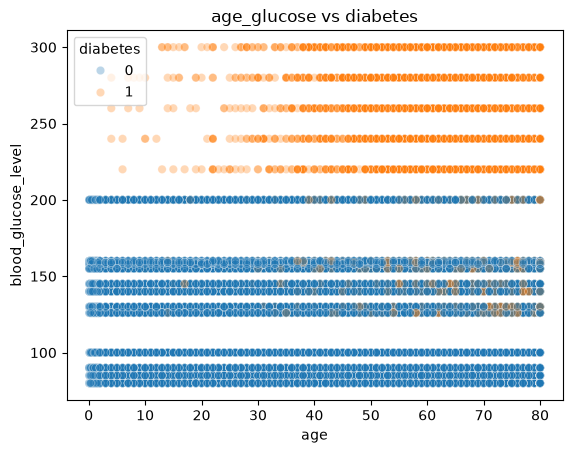

In [15]:
blood_glucose_bins = pd.cut(df["blood_glucose_level"], bins=[80, 100, 150, 200, 250, 300])
age_bins = pd.cut(df["age"], bins=[10, 20, 30, 50, 80, 100])
age_glucose_rate = (
    df.groupby([blood_glucose_bins, age_bins])["diabetes"]
    .aggregate(["mean", "count"])
    .rename(columns={"count": "Total", "mean": "Diabetes Rate"})
    )
print(age_glucose_rate)

sns.scatterplot(data=df, x="age", y="blood_glucose_level", hue="diabetes", alpha=0.3)
plt.title("age_glucose vs diabetes")
plt.show()

* Age vs Gender against Diabetes distribution

                     Rate  Total
age      gender                 
(10, 20] Female  0.007599     42
         Male    0.008838     42
         Other   0.000000      0
(20, 30] Female  0.013198    112
         Male    0.017516     76
         Other   0.000000      0
(30, 50] Female  0.047807    812
         Male    0.068146    737
         Other   0.000000      0
(50, 80] Female  0.155282   3478
         Male    0.197485   3172
         Other   0.000000      0


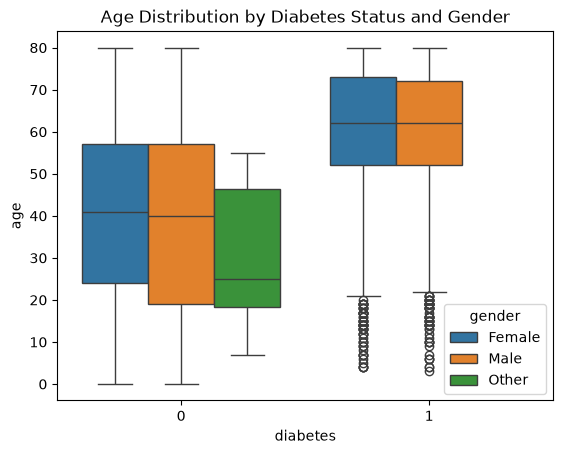

In [16]:
age_gender = (
    df.groupby([pd.cut(df["age"], bins=[10, 20, 30, 50, 80, 100]),"gender"])["diabetes"]
    .agg(["mean", "sum"])
    .rename(columns={"mean":"Rate", "sum":"Total"})
)
print(age_gender)

sns.boxplot(data=df, x="diabetes", y="age", hue="gender")
plt.title("Age Distribution by Diabetes Status and Gender")
plt.show()

* Gender vs BMI against Diabetes distribution

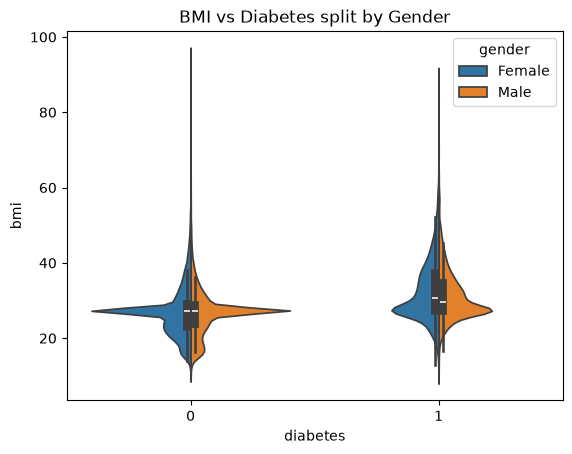

In [21]:
gender_bmi_data = df[df['gender'] != 'Other']

sns.violinplot(data=gender_bmi_data, x="diabetes", y="bmi", hue="gender", split=True)
plt.title("BMI vs Diabetes split by Gender")
plt.show()

* Hypertension vs Heart disease against Diabetes distribution

                                Rate  Total       std
hypertension heart_disease                           
0            0              0.061494   5503  0.240235
             1              0.300397    909  0.458506
1            0              0.263358   1730  0.440489
             1              0.390830    358  0.488203
heart_disease         0         1
hypertension                     
0              0.061494  0.300397
1              0.263358  0.390830


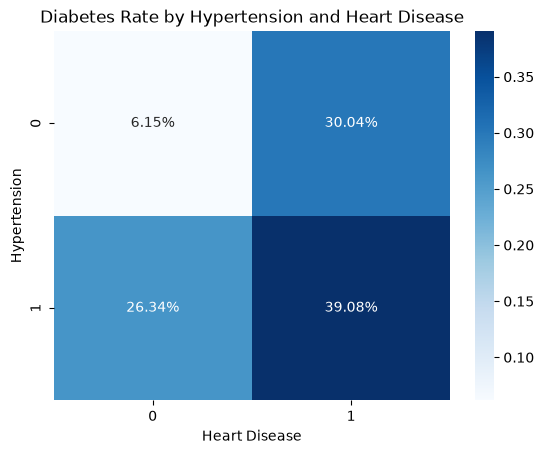

In [25]:
hyper_heart_rate = (
    df.groupby(["hypertension", "heart_disease"])["diabetes"]
    .agg(["mean", "sum", "std"])
    .rename(columns={"mean":"Rate", "sum":"Total"})
)
print(hyper_heart_rate)

pivot = df.pivot_table(
    index="hypertension",
    columns="heart_disease", values="diabetes", aggfunc="mean"
    )
print(pivot)

sns.heatmap(data=pivot, annot=True, fmt=".2%", cmap="Blues")

plt.title("Diabetes Rate by Hypertension and Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Hypertension")
plt.show()

#### Correlation

                          age  hypertension  heart_disease       bmi  \
age                  1.000000      0.251171       0.233354  0.337396   
hypertension         0.251171      1.000000       0.121262  0.147666   
heart_disease        0.233354      0.121262       1.000000  0.061198   
bmi                  0.337396      0.147666       0.061198  1.000000   
HbA1c_level          0.101354      0.080939       0.067589  0.082997   
blood_glucose_level  0.110672      0.084429       0.070066  0.091261   
diabetes             0.258008      0.197823       0.171727  0.214357   

                     HbA1c_level  blood_glucose_level  diabetes  
age                     0.101354             0.110672  0.258008  
hypertension            0.080939             0.084429  0.197823  
heart_disease           0.067589             0.070066  0.171727  
bmi                     0.082997             0.091261  0.214357  
HbA1c_level             1.000000             0.166733  0.400660  
blood_glucose_level     0.1

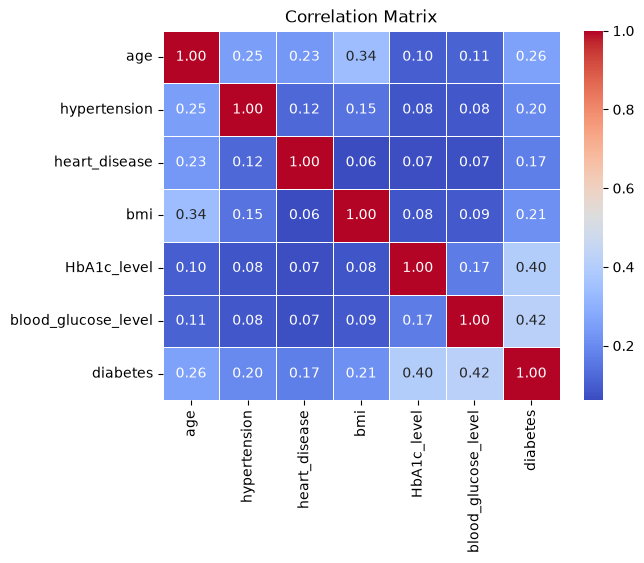

In [18]:
corr = df.select_dtypes(include="number").corr()
print(corr)
sns.heatmap(data=corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5)
plt.title("Correlation Matrix")
plt.show()

* Correlation with target variable

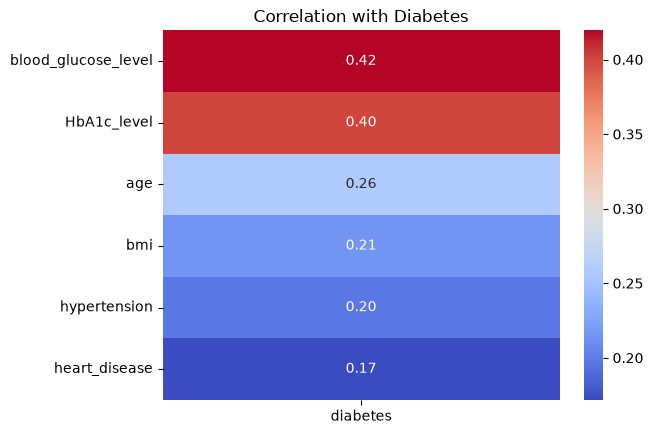

In [19]:
target_corr = corr['diabetes'].drop('diabetes').sort_values(ascending=False)

sns.heatmap(target_corr.to_frame(), cmap="coolwarm", annot=True, fmt='.2f')
plt.title('Correlation with Diabetes')
plt.show()

## EDA Review